In [1]:
%load_ext autoreload
%autoreload 2

Failed to read module file 'c:\Users\Lucio\miniconda3\envs\RL\Lib\re\_casefix.py' for module 're._casefix': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lucio\miniconda3\envs\RL\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1140, in _find_and_load_unlocked
ModuleN

In [2]:
import os
import sys
import gymnasium as gym
import yaml
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../envs"))
sys.path.append(os.path.abspath("../models"))
sys.path.append(os.path.abspath("../src"))

from utils_q_learning import *

In [3]:
with open("../config/q_learning_config.yaml", "r") as f:
    config = yaml.safe_load(f)

### 1)

In [10]:
experiment_folder = "parte1_1"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["alpha"]
gamma = config[experiment_folder]["gamma"]
epsilon = config[experiment_folder]["epsilon"]
seed = config["xtra"]["seed"]

model_1_path, _ = train_q_learning(experiment_folder, env, episodes, alpha, gamma, epsilon, seed=seed)

In [11]:
experiment_folder = "parte1_1"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
seed = config["xtra"]["seed"]

success_rate = evaluate_Q(model_1_path, env, episodes=100, epsilon=0.0, seed=seed)
print(f"Success rate: {success_rate:.2f}")

Success rate: 0.06


### 2)

In [12]:
experiment_folder = "parte1_2"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
gamma = config[experiment_folder]["gamma"]
seed = config["xtra"]["seed"]
alphas = [0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
epsilons = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
best_a_eps = search_hyperparameters(experiment_folder, env, episodes, gamma, alphas, epsilons, seed=seed)

Searching hyper:   0%|          | 0/88 [00:00<?, ?it/s]

Best epsilon for alpha 0.5: 0.4 with success rate 0.74
Best epsilon for alpha 0.1: 1.0 with success rate 0.76
Best epsilon for alpha 0.05: 1.0 with success rate 0.76
Best epsilon for alpha 0.01: 0.4 with success rate 0.76
Best epsilon for alpha 0.005: 0.4 with success rate 0.37
Best epsilon for alpha 0.001: 0.4 with success rate 0.25
Best epsilon for alpha 0.0005: 0.4 with success rate 0.25


In [13]:
experiment_folder = "parte1_2"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
gamma = config[experiment_folder]["gamma"]
seed = config["xtra"]["seed"]
alphas = best_a_eps.keys()
epsilons = best_a_eps.values()
results = []
for alpha, eps in zip(alphas, epsilons):  # to save the Q
    path, _ = train_q_learning(experiment_folder, env, episodes, alpha, gamma, eps, seed=seed)
    success_rate = evaluate_Q(path, env, episodes=100, epsilon=0.0, seed=seed)
    results.append((success_rate, alpha, eps))
    print(f"Alpha: {alpha}, Epsilon: {eps}, Success Rate: {success_rate:.2f}")

Alpha: 0.5, Epsilon: 0.4, Success Rate: 0.74
Alpha: 0.1, Epsilon: 1.0, Success Rate: 0.76
Alpha: 0.05, Epsilon: 1.0, Success Rate: 0.76
Alpha: 0.01, Epsilon: 0.4, Success Rate: 0.76
Alpha: 0.005, Epsilon: 0.4, Success Rate: 0.37
Alpha: 0.001, Epsilon: 0.4, Success Rate: 0.25
Alpha: 0.0005, Epsilon: 0.4, Success Rate: 0.25
Alpha: 0.0001, Epsilon: 0.4, Success Rate: 0.25


In [14]:
experiment_folder = "parte1_2"

# results should be a list of (success_rate, alpha, eps) from the previous cell
results_sorted = sorted(results, key=lambda x: x[0])
best_success_rate, best_alpha, best_epsilon = results_sorted[-1]
print(f"Best alpha: {best_alpha}, Best epsilon: {best_epsilon}")
config[experiment_folder]["best_alpha"] = best_alpha
config[experiment_folder]["best_epsilon"] = best_epsilon
with open("../config/q_learning_config.yaml", "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

Best alpha: 0.01, Best epsilon: 0.4


### 3)

In [15]:
experiment_folder = "parte1_2"

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["best_alpha"]
gamma = config[experiment_folder]["gamma"]
epsilon = config[experiment_folder]["best_epsilon"]

seed = config["xtra"]["seed"]
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
model3_path, _ = train_q_learning(experiment_folder, env, episodes, alpha, gamma, epsilon, seed=seed)

Experiment ../runs/q_learning/parte1_2/epi_10000_a_0.01_g_0.99_eps_0.4 already exists.


In [16]:
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
seed = config["xtra"]["seed"]
epsilons = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
succ_rates = []
for epsilon in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    success_rate = evaluate_Q(model3_path, env, episodes=100, epsilon=epsilon, seed=seed)
    succ_rates.append(success_rate)
    print(f"Success rate for epsilon {epsilon}: {success_rate:.2f}")


Success rate for epsilon 0.0: 0.76
Success rate for epsilon 0.1: 0.36
Success rate for epsilon 0.2: 0.20
Success rate for epsilon 0.3: 0.11
Success rate for epsilon 0.4: 0.10
Success rate for epsilon 0.5: 0.02
Success rate for epsilon 0.6: 0.06
Success rate for epsilon 0.7: 0.03
Success rate for epsilon 0.8: 0.03
Success rate for epsilon 0.9: 0.03
Success rate for epsilon 1.0: 0.01


In [17]:
experiment_2 = "parte1_2"
experiment_folder = "parte1_4"
config[experiment_folder]["gamma"] = config[experiment_2]["gamma"]
config[experiment_folder]["alpha"] = config[experiment_2]["best_alpha"]
with open("../config/q_learning_config.yaml", "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

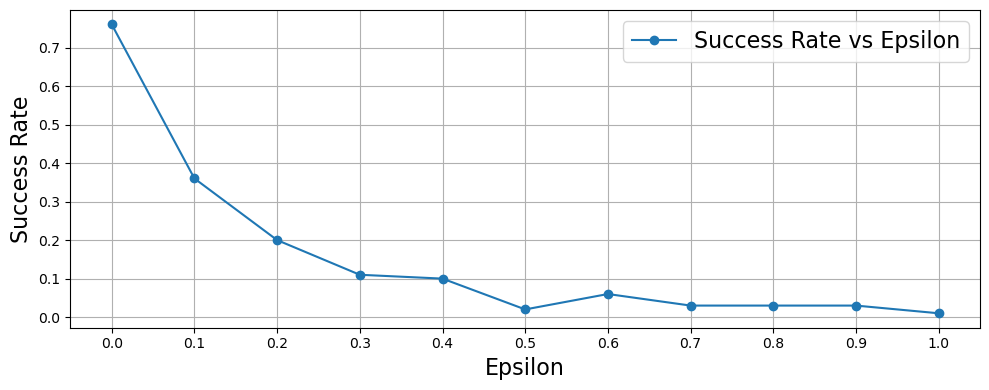

In [18]:
fig = plt.figure(figsize=(10, 4))
plt.plot(epsilons, succ_rates, marker='o', label="Success Rate vs Epsilon")
plt.xlabel("Epsilon", fontsize=16)
plt.ylabel("Success Rate", fontsize=16)
plt.xticks(epsilons)
plt.grid()
plt.tight_layout()
plt.legend(fontsize = 16)
path = Path("../images/succes_rate_vs_epsilon.png")
if not os.path.exists(path.parent):
    os.makedirs(path.parent)
plt.savefig(path, dpi=300)
plt.show()

### 4)

In [19]:
experiment_folder = "parte1_4"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
gamma = config[experiment_folder]["gamma"]
alpha = config[experiment_folder]["alpha"]
seed = config["xtra"]["seed"]
min_epsilons = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9]
max_epsilons = [0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 1.0]
decays_rate = [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 1.0]
# min_epsilons = [0.1, 0.2]
# max_epsilons = [0.2, 0.4]
# decays_rate = [0.01, 0.05]
best_max_decay, global_best = search_eps_decay(experiment_folder, env, episodes, gamma, alpha, min_epsilons, max_epsilons, decays_rate, seed)

Total hyperparameter combinations to evaluate: 252


Searching hyper:   0%|          | 0/252 [00:00<?, ?it/s]

In [20]:
print(global_best)

{'min_epsilon': 0.1, 'max_epsilon': 0.9, 'decay_rate': 0.2, 'success_rate': 0.76}


In [21]:
experiment_4 = "parte1_4"
experiment_folder = "parte1_5"
config[experiment_folder]["gamma"] = config[experiment_4]["gamma"]
config[experiment_folder]["alpha"] = config[experiment_4]["alpha"]
config[experiment_folder]["min_epsilon"] = global_best["min_epsilon"]
config[experiment_folder]["max_epsilon"] = global_best["max_epsilon"]
config[experiment_folder]["decay_rate"] = global_best["decay_rate"]
with open("../config/q_learning_config.yaml", "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

### 5)

In [4]:
experiment_folder = "parte1_5"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["alpha"]
gamma = config[experiment_folder]["gamma"]
min_epsilon = config[experiment_folder]["min_epsilon"]
max_epsilon = config[experiment_folder]["max_epsilon"]
decay_rate = config[experiment_folder]["decay_rate"]
seed = config["xtra"]["seed"]

model_5_path, Q = train_q_learning(experiment_folder, env, episodes, alpha, gamma, min_epsilon, max_epsilon, decay_rate, seed=seed)

Experiment ../runs/q_learning/parte1_5/epi_10000_a_0.01_g_0.99_eps_0.1_max_eps_0.9_decay_0.2 already exists.


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle


def softmax(x, temperature=1.0):
    x = np.array(x, dtype=np.float64)

    if temperature <= 0:
        raise ValueError("temperature debe ser mayor a 0")

    x = x / temperature
    x = x - np.max(x)
    exp_x = np.exp(x)

    return exp_x / np.sum(exp_x)


def q_to_action_probs(q_values, mode="softmax", temperature=0.2):
    """
    Convierte los valores Q(s,a) en probabilidades por acción.

    mode="softmax":
        transforma los Q-values en una distribución suave.

    mode="greedy":
        asigna probabilidad 1 a la mejor acción y 0 al resto.
    """

    q_values = np.array(q_values, dtype=np.float64)

    if mode == "softmax":
        return softmax(q_values, temperature=temperature)

    elif mode == "greedy":
        probs = np.zeros_like(q_values)
        best_action = np.argmax(q_values)
        probs[best_action] = 1.0
        return probs

    else:
        raise ValueError("mode debe ser 'softmax' o 'greedy'")


def plot_frozenlake_policy_probs(
    Q,
    env=None,
    mode="softmax",
    temperature=0.2,
    save_path=None,
    show_values=True,
    title="Política aprendida en FrozenLake"
):
    """
    Grafica la política aprendida para FrozenLake 4x4.

    Cada celda representa un estado.
    Cada celda se divide en 4 triángulos:
        acción 0: izquierda
        acción 1: abajo
        acción 2: derecha
        acción 3: arriba

    El color de cada triángulo representa la probabilidad de elegir esa acción.
    """

    Q = np.array(Q)

    if Q.shape != (16, 4):
        raise ValueError(f"Esta función espera Q.shape == (16, 4), pero recibió {Q.shape}")

    n_rows = 4
    n_cols = 4

    action_names = {
        0: "←",
        1: "↓",
        2: "→",
        3: "↑",
    }

    # Si se pasa env, intento leer el mapa para marcar S, F, H, G
    desc = None
    if env is not None and hasattr(env.unwrapped, "desc"):
        desc = env.unwrapped.desc.astype(str)

    probs_matrix = np.zeros_like(Q, dtype=np.float64)

    for s in range(16):
        probs_matrix[s] = q_to_action_probs(
            Q[s],
            mode=mode,
            temperature=temperature
        )

    fig, ax = plt.subplots(figsize=(8, 8))

    cmap = plt.cm.viridis
    norm = plt.Normalize(vmin=0.0, vmax=1.0)

    for s in range(16):
        row = s // n_cols
        col = s % n_cols

        x0 = col
        y0 = row
        x1 = col + 1
        y1 = row + 1

        cx = col + 0.5
        cy = row + 0.5

        # Triángulos por acción
        triangles = {
            0: [(x0, y0), (x0, y1), (cx, cy)],  # izquierda
            1: [(x0, y1), (x1, y1), (cx, cy)],  # abajo
            2: [(x1, y0), (x1, y1), (cx, cy)],  # derecha
            3: [(x0, y0), (x1, y0), (cx, cy)],  # arriba
        }

        for action in range(4):
            prob = probs_matrix[s, action]

            polygon = Polygon(
                triangles[action],
                closed=True,
                facecolor=cmap(norm(prob)),
                edgecolor="black",
                linewidth=0.7
            )

            ax.add_patch(polygon)

        # Borde de la celda
        rect = Rectangle(
            (x0, y0),
            1,
            1,
            fill=False,
            edgecolor="black",
            linewidth=1.5
        )
        ax.add_patch(rect)

        # Número de estado
        ax.text(
            cx,
            cy,
            f"s={s}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="white"
        )

        # Texto del tipo de celda si tengo el mapa
        if desc is not None:
            cell_type = desc[row, col]

            if cell_type in ["S", "H", "G"]:
                ax.text(
                    x0 + 0.08,
                    y0 + 0.16,
                    cell_type,
                    ha="left",
                    va="center",
                    fontsize=12,
                    fontweight="bold",
                    color="white"
                )

        if show_values:
            text_positions = {
                0: (x0 + 0.18, cy),       # izquierda
                1: (cx, y1 - 0.18),       # abajo
                2: (x1 - 0.18, cy),       # derecha
                3: (cx, y0 + 0.18),       # arriba
            }

            for action in range(4):
                tx, ty = text_positions[action]

                ax.text(
                    tx,
                    ty,
                    f"{action_names[action]}\n{probs_matrix[s, action]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white"
                )

    ax.set_xlim(0, n_cols)
    ax.set_ylim(0, n_rows)
    ax.invert_yaxis()
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_yticks(np.arange(n_rows) + 0.5)

    ax.set_xticklabels([f"col {i}" for i in range(n_cols)])
    ax.set_yticklabels([f"fila {i}" for i in range(n_rows)])

    ax.set_title(title)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Probabilidad de acción")

    fig.tight_layout()

    if save_path is not None:
        dir_name = os.path.dirname(save_path)

        if dir_name != "":
            os.makedirs(dir_name, exist_ok=True)

        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

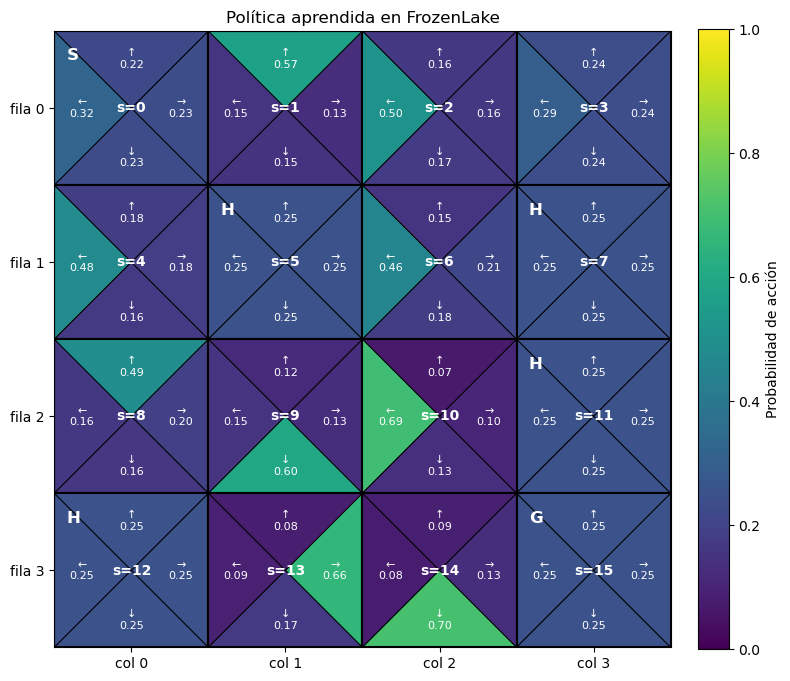

In [24]:
plot_frozenlake_policy_probs(
    Q=Q,
    env=env,
    mode="softmax",
    temperature=0.2,
    save_path="images/frozenlake_policy_probs.png",
    show_values=True
)

In [8]:
experiment_folder = "parte1_5"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
seed = config["xtra"]["seed"]

success_rate, truncateds = evaluate_Q(model_5_path, env, episodes=100, epsilon=0.0, seed=seed)
print(f"Success rate: {success_rate:.2f}")
print(f"Truncated episodes: {truncateds}")

Success rate: 0.76
Truncated episodes: 7


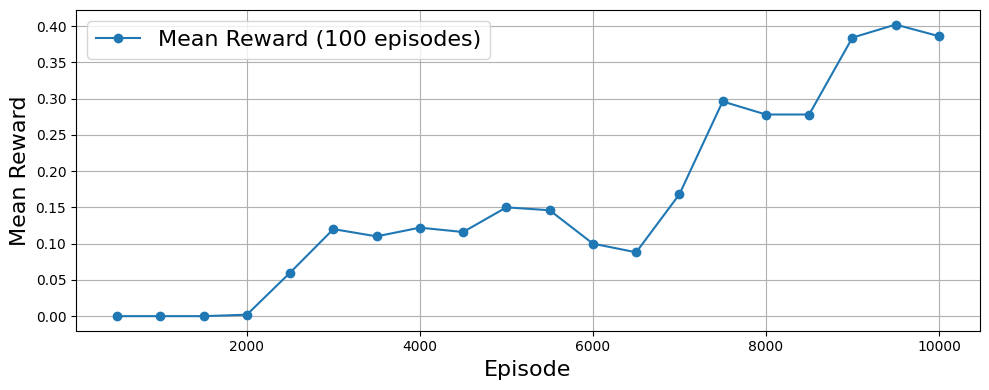

In [13]:
folder_name = "q_learning/parte1_5"
window = 500

plot_mean_rewards(folder_name, window)

### 6)

In [27]:
experiment_folder = "parte1_5"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["alpha"]
gamma = config[experiment_folder]["gamma"]
min_epsilon = config[experiment_folder]["min_epsilon"]
max_epsilon = config[experiment_folder]["max_epsilon"]
decay_rate = config[experiment_folder]["decay_rate"]
seed = config["xtra"]["seed"]

model_5_path, _ = train_q_learning(experiment_folder, env, episodes, alpha, gamma, min_epsilon, max_epsilon, decay_rate, seed=seed)

Experiment ../runs/q_learning/parte1_5/epi_10000_a_0.01_g_0.99_eps_0.1_max_eps_0.9_decay_0.2 already exists.


In [ ]:
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = "rgb_array")
experiment_name = "Frozen_lake_video"
num_episodes = 1
epsilon = 0.0
seed = config["xtra"]["seed"]

record_experiment(model_5_path, experiment_name, env, num_episodes, epsilon, seed)

/home/alumno1/miniconda3/envs/vision/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/alumno1/Documents/RL-TP2/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episode 1 | Total reward: 1
